Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline

Cell 2 — Load the data

In [2]:
df = pd.read_csv('../data/raw/outbreaks.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (19119, 12)


,Year,Month,State,Location,Food,Ingredient,Species,Serotype/Genotype,Status,Illnesses,Hospitalizations,Fatalities
0,1998,January,California,Restaurant,NaN,NaN,NaN,NaN,NaN,20,0.00,0.00
1,1998,January,California,NaN,Custard,NaN,NaN,NaN,NaN,112,0.00,0.00
2,1998,January,California,Restaurant,NaN,NaN,NaN,NaN,NaN,35,0.00,0.00
3,1998,January,California,Restaurant,"Fish, Ahi",NaN,Scombroid toxin,NaN,Confirmed,4,0.00,0.00
4,1998,January,California,Private Home/Residence,"Lasagna, Unspecified; Eggs, Other",NaN,Salmonella enterica,Enteritidis,Confirmed,26,3.00,0.00
5,1998,January,California,Restaurant,NaN,NaN,Shigella boydii,NaN,Confirmed,25,3.00,0.00
6,1998,January,California,Restaurant,NaN,NaN,NaN,NaN,NaN,8,0.00,0.00
7,1998,January,California,Restaurant,"Stuffing, Unspecified; Sandwich, Turkey",NaN,Salmonella enterica,Enteritidis,Confirmed,4,3.00,0.00
8,1998,January,Colorado,Restaurant,"Salad, Unspecified",NaN,Virus,NaN,Suspected,21,NaN,NaN
9,1998,January,Colorado,Restaurant,"Peppers, Chili",NaN,Virus,NaN,Suspected,3,NaN,0.00


Cell 3 — Column names and data types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19119 entries, 0 to 19118
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               19119 non-null  int64  
 1   Month              19119 non-null  object 
 2   State              19119 non-null  object 
 3   Location           16953 non-null  object 
 4   Food               10156 non-null  object 
 5   Ingredient         1876 non-null   object 
 6   Species            12500 non-null  object 
 7   Serotype/Genotype  3907 non-null   object 
 8   Status             12500 non-null  object 
 9   Illnesses          19119 non-null  int64  
 10  Hospitalizations   15494 non-null  float64
 11  Fatalities         15518 non-null  float64
dtypes: float64(2), int64(2), object(8)
memory usage: 1.8+ MB


Cell 4 — Missing values analysis


In [4]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing)

                   Missing Count  Missing %
Ingredient                 17243      90.19
Serotype/Genotype          15212      79.56
Food                        8963      46.88
Species                     6619      34.62
Status                      6619      34.62
Hospitalizations            3625      18.96
Fatalities                  3601      18.83
Location                    2166      11.33


Cell 5 — Basic statistics


In [5]:
df.describe()

,Year,Illnesses,Hospitalizations,Fatalities
count,19119.00,19119.00,15494.00,15518.00
mean,2005.56,19.54,0.95,0.02
std,5.16,49.45,5.31,0.39
min,1998.00,2.00,0.00,0.00
25%,2001.00,3.00,0.00,0.00
50%,2005.00,8.00,0.00,0.00
75%,2010.00,19.00,1.00,0.00
max,2015.00,1939.00,308.00,33.00


Cell 6 — Categorical columns overview

In [6]:
categorical_cols = ['Month', 'State', 'Location', 'Food', 'Species', 'Status']

for col in categorical_cols:
    print(f"\n{col} — {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))
    print("-" * 50)


Month — 12 unique values
Month
May         1898
June        1819
December    1816
April       1725
March       1724
July        1538
August      1533
January     1515
November    1509
February    1448
Name: count, dtype: int64
--------------------------------------------------

State — 55 unique values
State
Florida       2409
California    2293
Ohio          1288
Illinois      1133
New York       909
Michigan       882
Minnesota      842
Washington     824
Maryland       816
Colorado       510
Name: count, dtype: int64
--------------------------------------------------

Location — 161 unique values
Location
Restaurant                            10448
Private Home/Residence                 1681
Catering Service                       1089
Banquet Facility                        367
Fast Food Restaurant                    366
Unknown                                 355
School/College/University               354
Grocery Store                           301
Restaurant; Private Home/Reside

Cell 7 — Check for duplicates


In [7]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
print(f"Duplicate rows %: {duplicates / len(df) * 100:.2f}%")

Duplicate rows: 280
Duplicate rows %: 1.46%


Cell 8 — Distribution of the numerical columns


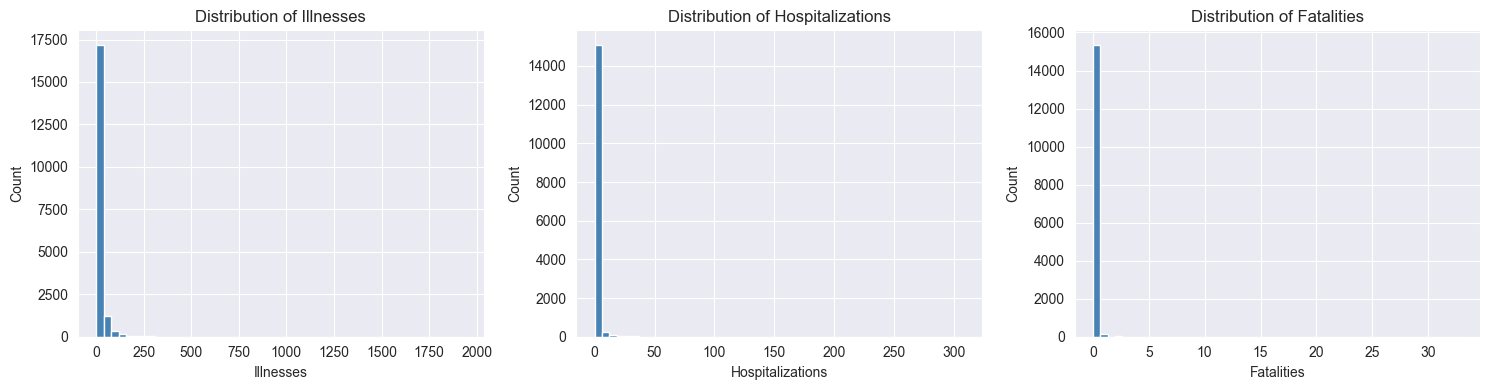

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Illnesses', 'Hospitalizations', 'Fatalities']):
    df[col].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/figures/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 9 — Outbreaks over time


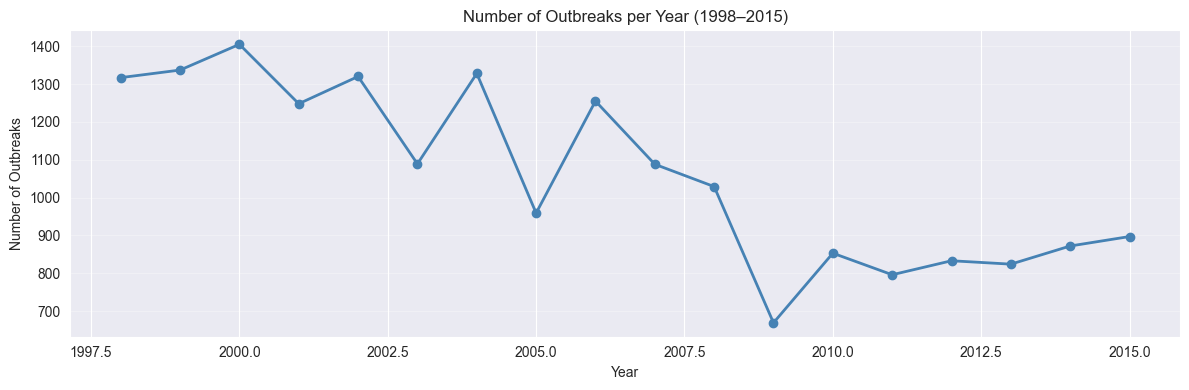

In [9]:
yearly = df.groupby('Year').size().reset_index(name='Outbreaks')

plt.figure(figsize=(12, 4))
plt.plot(yearly['Year'], yearly['Outbreaks'], marker='o', linewidth=2, color='steelblue')
plt.title('Number of Outbreaks per Year (1998–2015)')
plt.xlabel('Year')
plt.ylabel('Number of Outbreaks')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/02_outbreaks_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 10 — Top pathogens


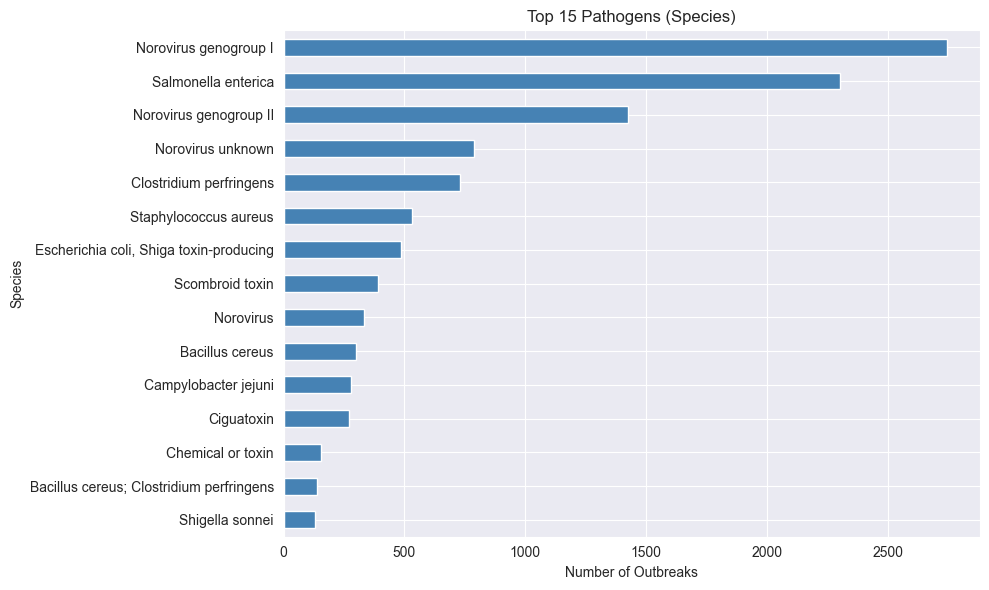

In [10]:
top_species = df['Species'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_species.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 Pathogens (Species)')
plt.xlabel('Number of Outbreaks')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/03_top_pathogens.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 11 — Top outbreak locations


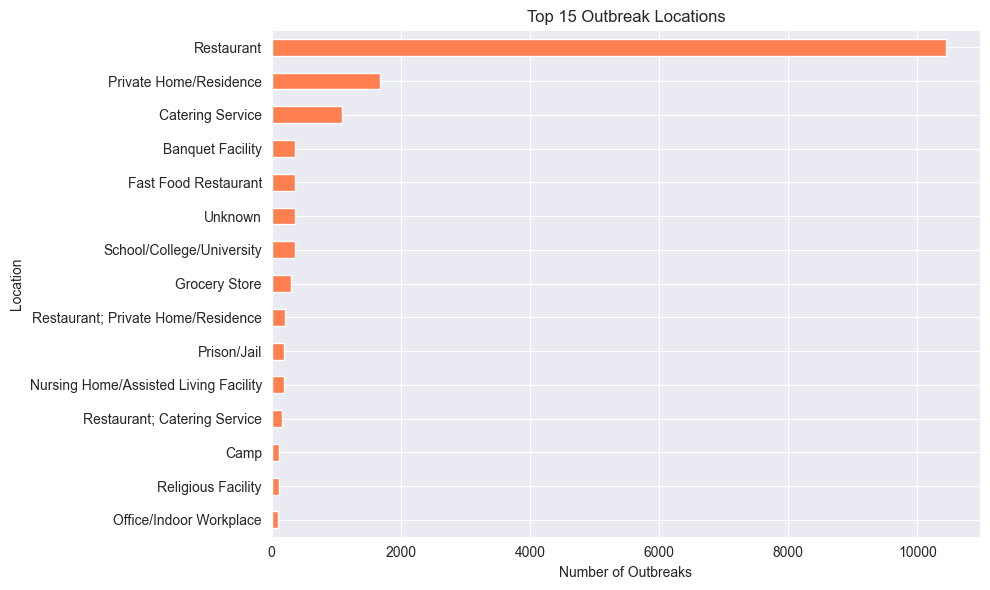

In [11]:
top_locations = df['Location'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_locations.plot(kind='barh', color='coral', edgecolor='white')
plt.title('Top 15 Outbreak Locations')
plt.xlabel('Number of Outbreaks')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/04_top_locations.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 12 — Outbreaks by month


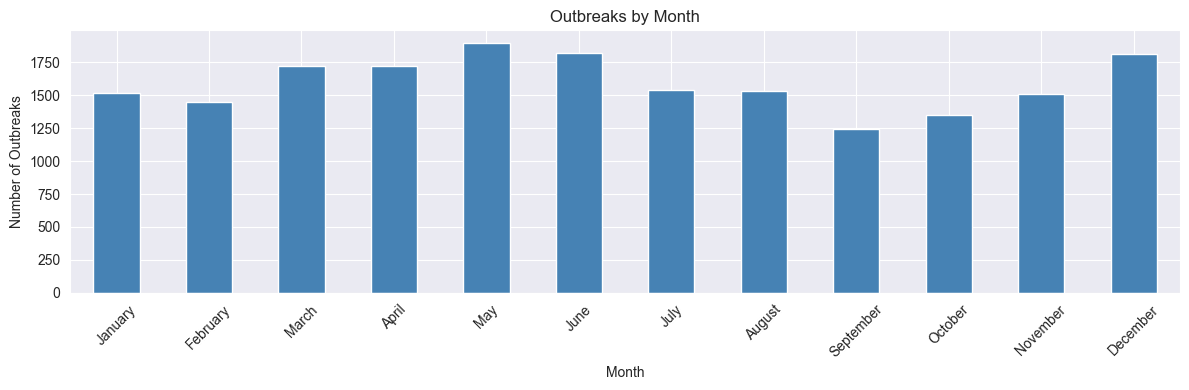

In [12]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = df.groupby('Month').size().reindex(month_order)

plt.figure(figsize=(12, 4))
monthly.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Outbreaks by Month')
plt.xlabel('Month')
plt.ylabel('Number of Outbreaks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/05_outbreaks_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 13 — Correlation between numerical columns


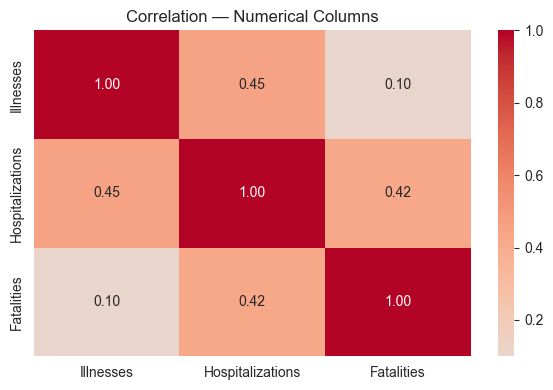

In [13]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[['Illnesses', 'Hospitalizations', 'Fatalities']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation — Numerical Columns')
plt.tight_layout()
plt.savefig('../reports/figures/06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 14 — Key findings

## Key Findings from EDA

1. **Dataset:** 19,119 outbreaks, 12 columns, 1998–2015 (United States)
2. **Columns to drop:** Ingredient (90% missing), Serotype/Genotype (80% missing)
3. **Missing data strategy needed:** Food (47%), Species (35%), Location (11%)
4. **Target variable:** Illnesses is heavily right-skewed (median=8, max=1939) — need thresholds
5. **Top pathogen:** Norovirus genogroup I (2,744 occurrences)
6. **Top location:** Restaurant (10,448 occurrences — 62% of known locations)
7. **Seasonal pattern:** May/June peak + December spike (holiday gatherings)
8. **Status column:** Compound values ("Confirmed; Confirmed") need parsing
9. **Location column:** 161 unique values including compound ones — needs simplification